In [ ]:
# Week 4 – Pandas, Visualization & Machine Learning
# ASSIGNMENT 1: Pandas DataFrame Master
# Objective: Perform merging, grouping, concatenation and binning operations in Pandas.

# Steps:
# 1. Import pandas as pd and numpy as np.
# 2. Create Employees, Departments and Salaries DataFrames.
# 3. Perform merging:
#    - Inner join between employees and departments
#    - Left join between employees and departments
#    - Full outer join between employees and departments
# 4. Concatenate new employee records vertically.
# 5. Merge employees with salaries to create emp_salary.
# 6. Use groupby to calculate average salary by department.
# 7. Create salary bins using:
#    bins = [0, 60000, 80000, 100000]
#    labels = ['Low','Medium','High']
#    Use pd.cut() to create a new column salary_category.
# 8. Save final DataFrame to CSV file employee_summary.csv.
# Expected Skills:
# - pd.merge()
# - pd.concat()
# - groupby()
# - pd.cut()
# - df.to_csv()
# 1. Import libraries
import pandas as pd
import numpy as np

# 2. Create DataFrames
# Employees DataFrame
employees = pd.DataFrame({
    'EmpID': [1,2,3,4],
    'Name': ['Ali','Sara','Ahmed','Ayesha'],
    'DeptID': [101,102,101,103]
})
# Departments DataFrame
departments = pd.DataFrame({
    'DeptID': [101,102,104],
    'Department': ['HR','IT','Finance']
})
# Salaries DataFrame
salaries = pd.DataFrame({
    'EmpID': [1,2,3,4],
    'Salary': [50000,75000,90000,65000]
})
print("Employees:\n", employees)
print("\nDepartments:\n", departments)
print("\nSalaries:\n", salaries)

# 3. Merging
# Inner Join
inner_join = pd.merge(employees, departments, on='DeptID', how='inner')
print("\nInner Join:\n", inner_join)
# Left Join
left_join = pd.merge(employees, departments, on='DeptID', how='left')
print("\nLeft Join:\n", left_join)
# Full Outer Join
outer_join = pd.merge(employees, departments, on='DeptID', how='outer')
print("\nFull Outer Join:\n", outer_join)

# 4. Concatenate new employees
new_employees = pd.DataFrame({
    'EmpID': [5,6],
    'Name': ['Bilal','Zara'],
    'DeptID': [102,104]
})
employees = pd.concat([employees, new_employees], ignore_index=True)
print("\nAfter Concatenation:\n", employees)

# 5. Merge employees with salaries
emp_salary = pd.merge(employees, salaries, on='EmpID', how='left')
print("\nEmployee Salary:\n", emp_salary)

# 6. Groupby (Average Salary by Department)
avg_salary = emp_salary.groupby('DeptID')['Salary'].mean()
print("\nAverage Salary by Department:\n", avg_salary)

# 7. Binning (Salary Categories)
bins = [0, 60000, 80000, 100000]
labels = ['Low','Medium','High']
emp_salary['salary_category'] = pd.cut(emp_salary['Salary'], bins=bins, labels=labels)
print("\nAfter Binning:\n", emp_salary)

# 8. Save to CSV
emp_salary.to_csv("employee_summary.csv", index=False)
print("\nCSV file saved successfully!")


  month  product_a  product_b  product_c region
0   Jan        100         80         60  North
1   Feb        120         95         70  South
2   Mar        130        100         75   East
3   Apr         90        110         85   West
4   May        150        120         95  North
5   Jun        170        140        100  South


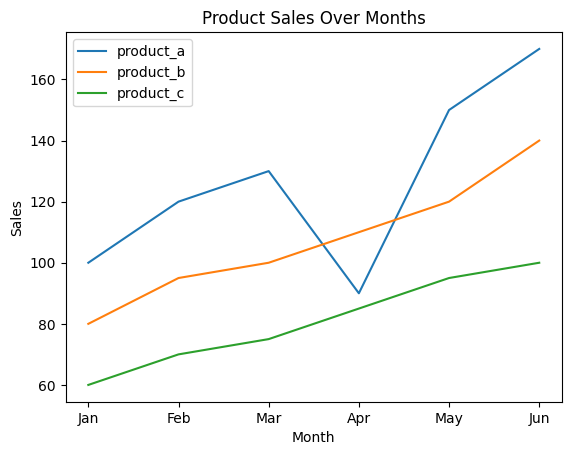

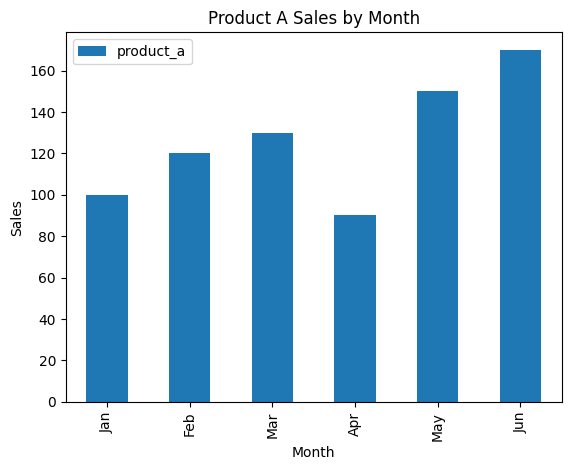

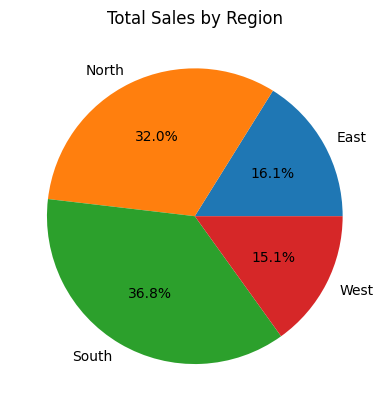

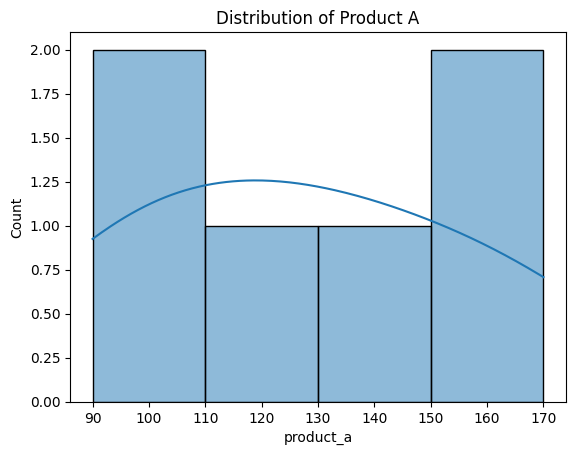

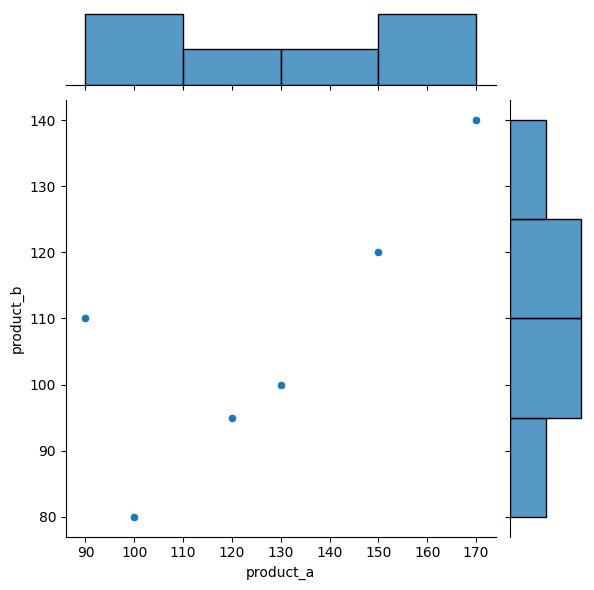

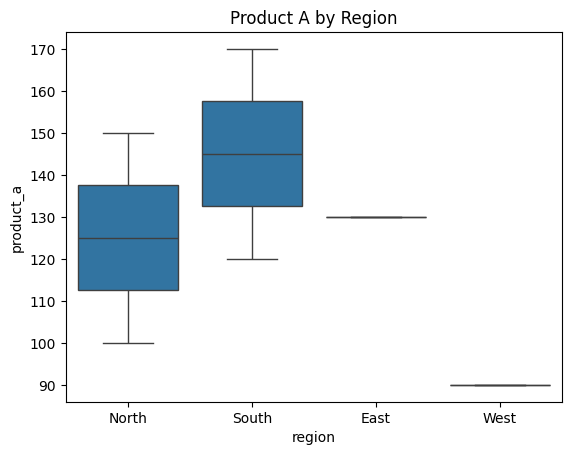

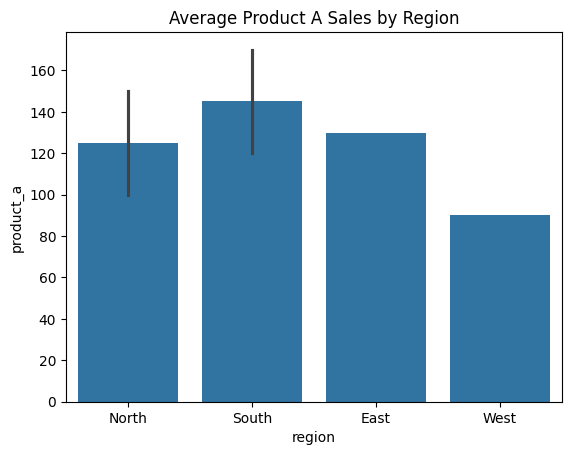

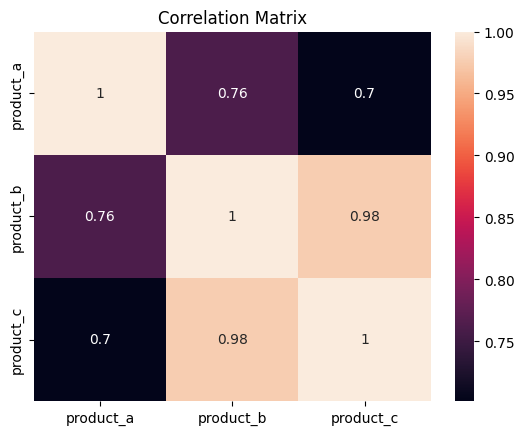

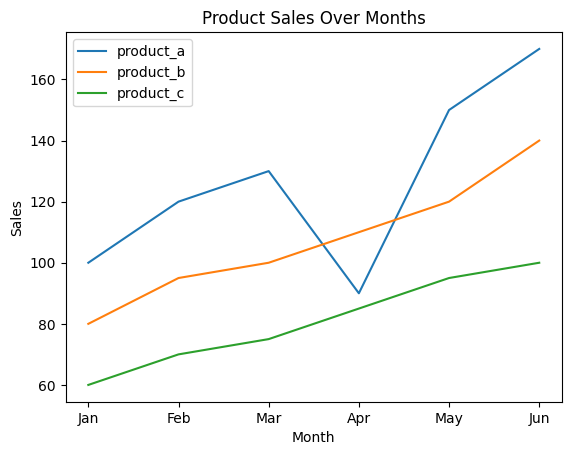

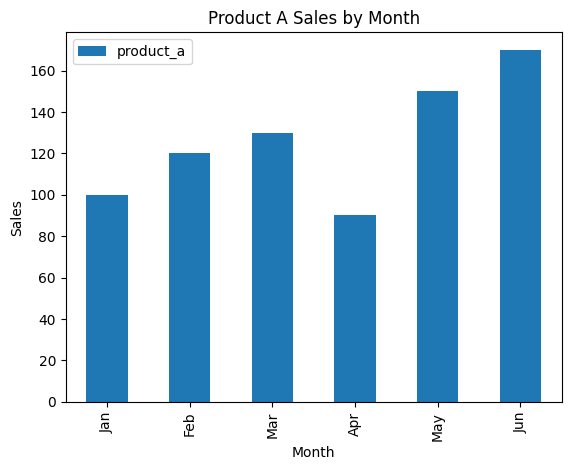

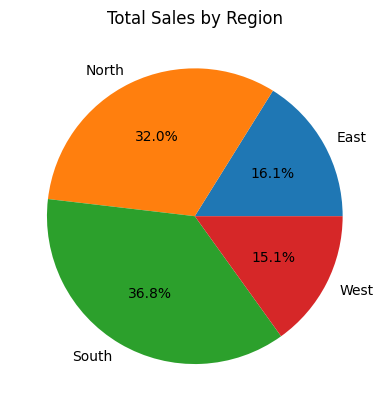

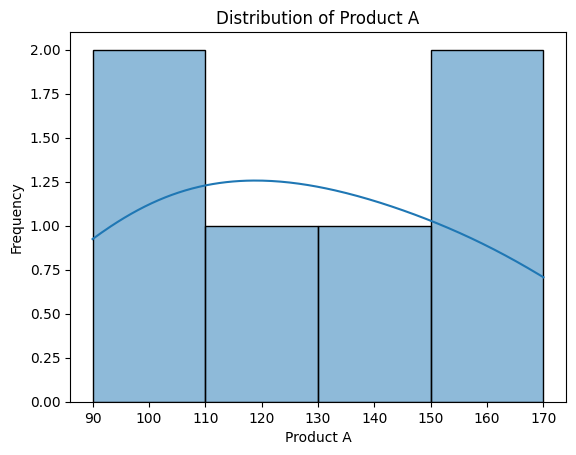

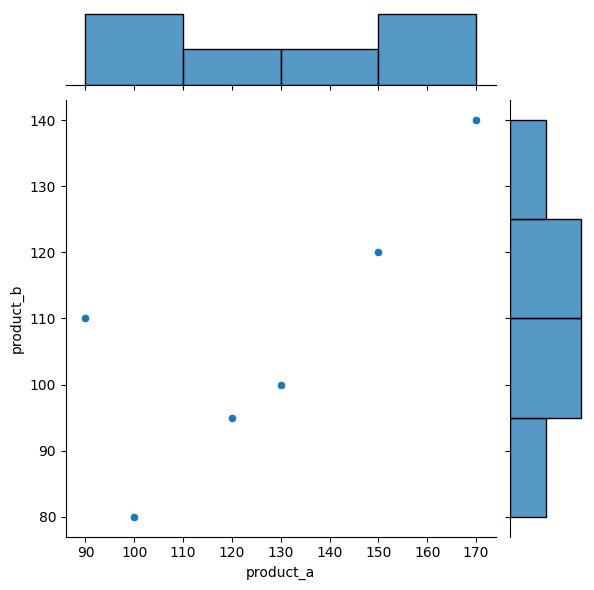

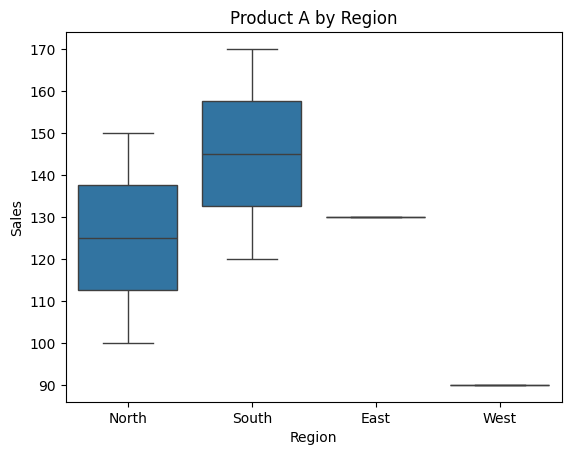

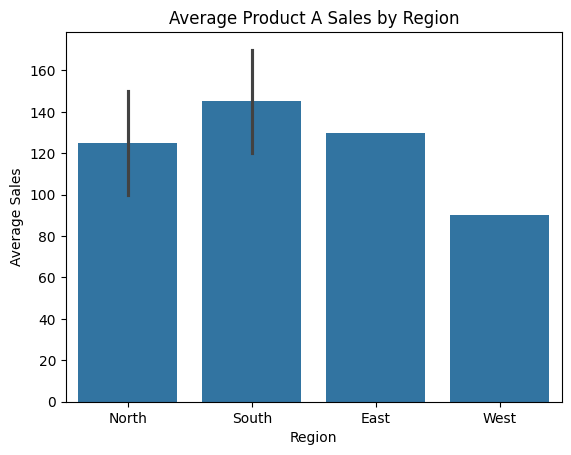

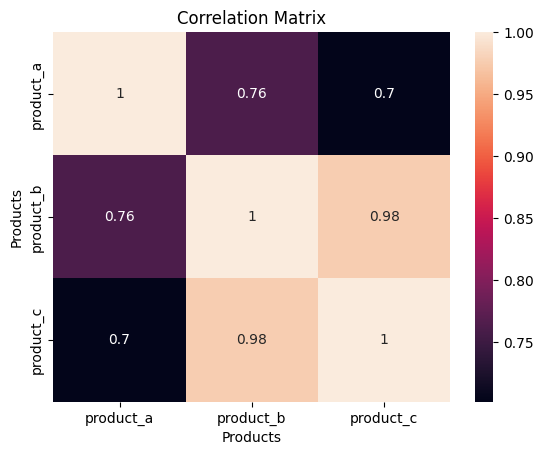

In [1]:
# ASSIGNMENT 2: Data Visualization with Pandas and Seaborn
# Objective: Create multiple visualizations using Pandas plotting and Seaborn.
# Steps:
# 1. Import pandas as pd, matplotlib.pyplot as plt and seaborn as sns.
# 2. Create the sales dataset with columns:
#    month, product_a, product_b, product_c, region.
# 3. Pandas Visualizations:
#    - Line plot of product sales over months
#    - Bar plot of product_a by month
#    - Pie chart of total sales by region
# 4. Seaborn Distribution Plots:
#    - distplot for product_a
#    - jointplot comparing product_a and product_b
# 5. Seaborn Categorical Plots:
#    - boxplot for product_a by region
#    - barplot showing average product sales by region
# 6. Matrix Plot:
#    - Create correlation matrix of product columns
#    - Visualize using sns.heatmap()
# 7. Add titles, labels and call plt.show() for each plot.

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create dataset
data = {
    'month': ['Jan','Feb','Mar','Apr','May','Jun'],
    'product_a': [100,120,130,90,150,170],
    'product_b': [80,95,100,110,120,140],
    'product_c': [60,70,75,85,95,100],
    'region': ['North','South','East','West','North','South']
}
df = pd.DataFrame(data)
print(df)

# ---------------------------
# 3. Pandas Visualizations
# ---------------------------
# Line plot (product sales over months)
df.set_index('month')[['product_a','product_b','product_c']].plot(kind='line')
plt.title("Product Sales Over Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
# Bar plot (product_a by month)
df.plot(x='month', y='product_a', kind='bar')
plt.title("Product A Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
# Pie chart (total sales by region)
region_sales = df.groupby('region')[['product_a','product_b','product_c']].sum().sum(axis=1)
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Total Sales by Region")
plt.ylabel("")
plt.show()

# ---------------------------
# 4. Seaborn Distribution Plots
# ---------------------------
# Distplot (for product_a)
sns.histplot(df['product_a'], kde=True)
plt.title("Distribution of Product A")
plt.show()
# Jointplot (product_a vs product_b)
sns.jointplot(x='product_a', y='product_b', data=df)
plt.show()


# ---------------------------
# 5. Seaborn Categorical Plots
# ---------------------------
# Boxplot
sns.boxplot(x='region', y='product_a', data=df)
plt.title("Product A by Region")
plt.show()
# Barplot (average sales by region)
sns.barplot(x='region', y='product_a', data=df)
plt.title("Average Product A Sales by Region")
plt.show()

# ---------------------------
# 6. Matrix Plot
# ---------------------------
# Correlation matrix
corr = df[['product_a','product_b','product_c']].corr()
# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# 7. Add titles, labels and call plt.show() for each plot.
# Line Plot
df.set_index('month')[['product_a','product_b','product_c']].plot(kind='line')
plt.title("Product Sales Over Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Bar Plot
df.plot(x='month', y='product_a', kind='bar')
plt.title("Product A Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Pie Chart
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Total Sales by Region")
plt.ylabel("")  # optional (pie chart mein y-label hata dete hain)
plt.show()

# Histogram / Distribution Plot
sns.histplot(df['product_a'], kde=True)
plt.title("Distribution of Product A")
plt.xlabel("Product A")
plt.ylabel("Frequency")
plt.show()

# Joint Plot (Seaborn automatically handles labels)
sns.jointplot(x='product_a', y='product_b', data=df)
plt.show()

# Box Plot
sns.boxplot(x='region', y='product_a', data=df)
plt.title("Product A by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# Bar Plot (Seaborn)
sns.barplot(x='region', y='product_a', data=df)
plt.title("Average Product A Sales by Region")
plt.xlabel("Region")
plt.ylabel("Average Sales")
plt.show()

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.xlabel("Products")
plt.ylabel("Products")
plt.show()

Epoch 0: Cost = 4032.5000
Epoch 100: Cost = 84.7902
Epoch 200: Cost = 37.7160
Epoch 300: Cost = 17.4276
Epoch 400: Cost = 8.6836
Epoch 500: Cost = 4.9150
Epoch 600: Cost = 3.2908
Epoch 700: Cost = 2.5908
Epoch 800: Cost = 2.2891
Epoch 900: Cost = 2.1591

Final slope (m): 5.5488
Final intercept (b): 30.8883
Predicted score for 4.5 hours: 55.86
Predicted score for 7.5 hours: 72.50


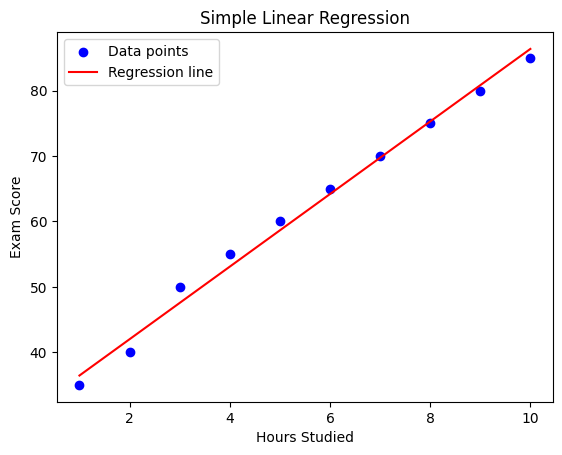

In [12]:
# ASSIGNMENT 3: Simple Linear Regression from Scratch
# Objective: Implement linear regression using gradient descent.
# Dataset:
# Hours studied vs exam score
# Steps:
# 1. Import numpy and matplotlib.
# 2. Create dataset:
#    X = hours studied
#    y = exam scores
# 3. Initialize parameters:
#    m = 0
#    b = 0
#    learning rate = 0.01
#    epochs = 1000
# 4. Implement prediction:
#    y_pred = m*X + b
# 5. Implement cost function:
#    Mean Squared Error
# 6. Compute gradients:
#    m_gradient
#    b_gradient
# 7. Update parameters using gradient descent.
# 8. Print cost every 100 epochs.
# 9. After training:
#    Print final slope and intercept.
# 10. Make predictions for:
#     4.5 hours
#     7.5 hours
# 11. Plot:
#     Scatter plot of data
#     Regression line
 # 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Create dataset
X = np.array([1,2,3,4,5,6,7,8,9,10])  # hours studied
y = np.array([35,40,50,55,60,65,70,75,80,85])  # exam scores

# 3. Initialize parameters
m = 0  # slope
b = 0  # intercept
learning_rate = 0.01
epochs = 1000
n = len(X)  # number of data points

# 4. Prediction
y_pred = m*X + b
# 5. Define cost function (Mean Squared Error)
def compute_cost(y_true, y_pred):
    return (1/n) * np.sum((y_true - y_pred)**2)
# 6. Compute gradients
    m_gradient = (-2/n) * np.sum(X * (y - y_pred))
    b_gradient = (-2/n) * np.sum(y - y_pred)
# 7. Update parameters
    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient

# 8. Print cost every 100 epochs
for i in range(epochs):
    y_pred = m*X + b
    error = y - y_pred
    cost = (1/n) * np.sum(error**2)

    m_gradient = (-2/n) * np.sum(X * error)
    b_gradient = (-2/n) * np.sum(error)

    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient

    if i % 100 == 0:  # ✅ use 'i' instead of 'epoch'
        print(f"Epoch {i}: Cost = {cost:.4f}")

# 9. Print final slope and intercept
print(f"\nFinal slope (m): {m:.4f}")
print(f"Final intercept (b): {b:.4f}")

# 10. Make predictions
hours_to_predict = np.array([4.5, 7.5])
predictions = m*hours_to_predict + b
for h, p in zip(hours_to_predict, predictions):
    print(f"Predicted score for {h} hours: {p:.2f}")

# 11. Plot data and regression line
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, m*X + b, color='red', label='Regression line')
plt.title("Simple Linear Regression")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()
